## User Notebook - Synthesis from Statistics

The library supports **data synthesis** based on target maps/statistics. This notebook demonstrates how to use a **user-level wrapper** to generate syntheses directly from the statistical properties of a target image, rather than from the image itself.

Examples are provided to illustrate typical workflows.

**Note:**

- For **2D Kernel Data** and **2D FFT Data**, the set of optimized statistics (mean, variance, scattering coefficients, power spectrum, etc.) is defined from the target statistics provided to the wrapper. These statistics are computed upstream, before calling the user-level wrapper. The choice of which statistics to optimize is therefore made in advance during the computation of the target statistics passed to the wrapper, rather than inside the synthesis procedure itself.

The **power spectrum** is currently not optimized when NaN values are present in either the target or the running map. This may be supported in the future for the kernel dataclass by implementing power spectrum estimation via convolution.

Spatial dimensions of the target used to compute the statistics and those of the optimized maps must currently be identical. 

In addition, the number of maps per batch (**Nb**) along the batch dimension must be the same between the target used to compute the statistics and the optimized maps. As a result, it is not possible to synthesize a different number of maps than the one used in the original target statistics.

In [ ]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
from pathlib import Path
import sys

from types import SimpleNamespace


# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch, WaveletOperator2Dkernel_torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
from STL_main.Synthesis import synthesize_from_stats
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: cuda


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [3]:
def plot_target_vs_synthesis(target, synthesis, suptitle, titles=["Target", "Synthesis"]):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    t = target.cpu().numpy()
    u = synthesis.cpu().numpy()

    # Color scale limits of the target image, ignoring NaNs
    mean_t = np.nanmean(t)
    std_t = np.nanstd(t)

    vmin = mean_t - 3 * std_t
    vmax = mean_t + 3 * std_t

    im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[0].axis("off")
    axes[0].set_title(titles[0])

    im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[1].axis("off")
    axes[1].set_title(titles[1])

    fig.colorbar(im0, ax=axes, shrink=0.7)

    fig.suptitle(suptitle, fontsize=16)

    plt.show()

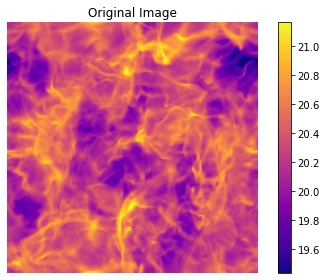

In [4]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Display original image
im_plot = plt.imshow(
    im[0, 0, :, :],
    cmap="plasma",
    vmin=np.nanmean(im) - 3 * np.nanstd(im),
    vmax=np.nanmean(im) + 3 * np.nanstd(im)
)
plt.title("Original Image")
plt.axis('off')
plt.colorbar(im_plot)
plt.tight_layout()
plt.show()

**The synthesis table below** summarizes all the syntheses performed in this certification notebook. It is not exhaustive: for example, it would be possible to perform FFT syntheses for many categories (except for syntheses where either the target, the running map, or both contain a mask).

| Category | Input image(s) | Output image(s) | Channel(s) | Method(s) |
|----------|---------------|-----------------|---------|--------|
| One → One | 1 PBC image | 1 PBC image | Mono + Cross | Kernel + FFT |
| Many → Many (N = M) | N PBC image | N PBC images | Mono | Kernel |
| PBC → Non PBC | 1 PBC image | 1 non-PBC image | Mono | Kernel |
| Non PBC → PBC | 1 non-PBC image | 1 PBC image | Mono | Kernel |
| Non PBC → Non PBC | 1 non-PBC image | 1 non-PBC image | Mono | Kernel |
| NaNs → NaNs | 1 image with NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → NaNs (≠ Mask)| 1 image with NaNs  | 1 image with NaNs | Mono | Kernel |
| Non NaNs → NaNs | 1 image without NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → Non NaNs | 1 image with NaNs | 1 image without NaNs | Mono | Kernel |


#### 1. One → One 

##### 1.1 Kernel - Mono Channel

In [7]:
im_target = im[0, 0, :, :] # Target image (mono-channel)

# Instantiate kernel data class and related ST operator
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)
st_op_target = data_target_kernel.get_ST_op()

# Standardize target data (should be performed outside the user-level synthesis-from-statistics wrapper)
data_target_kernel_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel, mean_field=False, inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_std)

# Call user-level synthesis-from-statistics wrapper
u_kernel = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
[LBFGS] iter 10, loss = 6.891676e+03
[LBFGS] iter 20, loss = 3.118974e+01
[LBFGS] iter 30, loss = 1.020218e+01
[LBFGS] iter 40, loss = 2.557892e+00
[LBFGS] iter 50, loss = 1.239030e+00
[LBFGS] iter 60, loss = 7.127271e-01
[LBFGS] iter 70, loss = 4.871672e-01
[LBFGS] iter 80, loss = 3.471469e-01
[LBFGS] iter 90, loss = 2.907014e-01
[LBFGS] iter 100, loss = 2.409494e-01
[LBFGS] iter 110, loss = 2.147744e-01
110 iterations of synthesis.
Execution time: 16.000 s


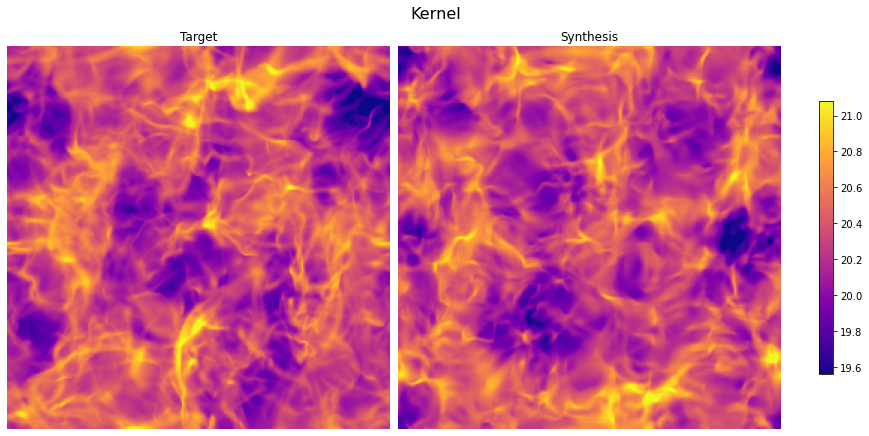

In [8]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_kernel.array, u_kernel, suptitle = "Kernel", titles=["Target", "Synthesis"])

##### 1.2 FFT - Mono Channel

Since the power spectrum is systematically included in the synthesis optimization, it is necessary in mono-channel FFT to increase the number of iterations, as the power spectrum dominates the scattering coefficients in the loss.

In [9]:
im_target = im[0, 0, :, :] # Target image (mono-channel)

# Instantiate fft data class and related ST operator
data_target_fft = STL_2D_FFT_Torch(im_target, pbc=True)
st_op_target = data_target_fft.get_ST_op()

# Standardize target data
data_target_fft_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_fft, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_fft_std)

# Call user-friendly synthesis wrapper
u_fft = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
[LBFGS] iter 10, loss = 6.623499e+03
[LBFGS] iter 20, loss = 2.363787e+01
[LBFGS] iter 30, loss = 3.144808e+00
[LBFGS] iter 40, loss = 5.738591e-01
[LBFGS] iter 50, loss = 2.474178e-01
[LBFGS] iter 60, loss = 1.474986e-01
[LBFGS] iter 70, loss = 1.083658e-01
[LBFGS] iter 80, loss = 8.419169e-02
[LBFGS] iter 90, loss = 6.793618e-02
[LBFGS] iter 100, loss = 4.141111e-02
108 iterations of synthesis.
Execution time: 10.980 s


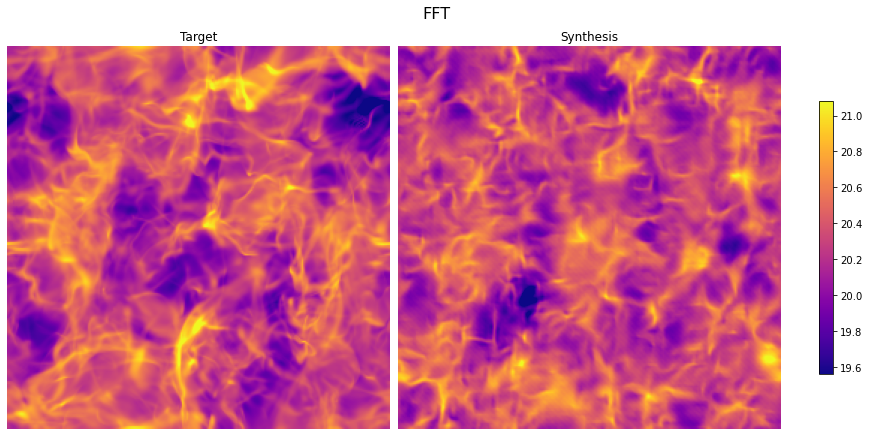

In [10]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_fft.array, u_fft, suptitle = "FFT", titles=["Target", "Synthesis"])

##### 1.3 Kernel - Multi Channels

In [15]:
# Make a multi-channel target image
im_target = np.stack([im[0, 0, :, :], (im[0 ,0, :, :]-im[0, 0, :, :].mean(keepdims=True))**2])
im_target -= im_target.mean(axis=(1,2), keepdims=True)

# Instantiate kernel data class and related ST operator
data_target_kernel_multi_channel = STL_2D_FFT_Torch(im_target, pbc=True)
st_op_target = data_target_kernel_multi_channel.get_ST_op()

# Standardize target data
data_target_kernel_multi_channel_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_multi_channel, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)
target_stats = st_op_target.apply(
    data_target_kernel_multi_channel_std, 
    compute_cross_matrix=compute_cross_matrix
)

# Call user-friendly synthesis wrapper
u_kernel_multi_channel = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 2, 256, 256)
[LBFGS] iter 10, loss = 1.286966e+04
[LBFGS] iter 20, loss = 4.941573e+01
[LBFGS] iter 30, loss = 1.228030e+01
[LBFGS] iter 40, loss = 3.300025e+00
[LBFGS] iter 50, loss = 1.350901e+00
[LBFGS] iter 60, loss = 7.624102e-01
[LBFGS] iter 70, loss = 5.138401e-01
[LBFGS] iter 80, loss = 3.767374e-01
[LBFGS] iter 90, loss = 2.700567e-01
[LBFGS] iter 100, loss = 2.070913e-01
108 iterations of synthesis.
Execution time: 26.216 s


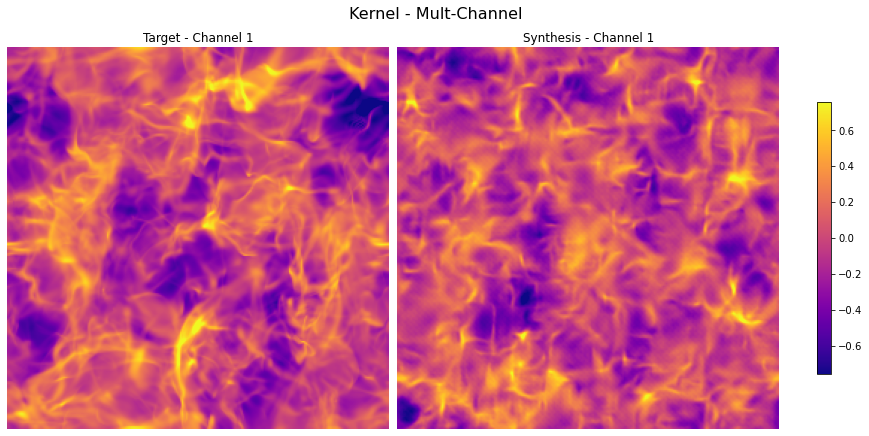

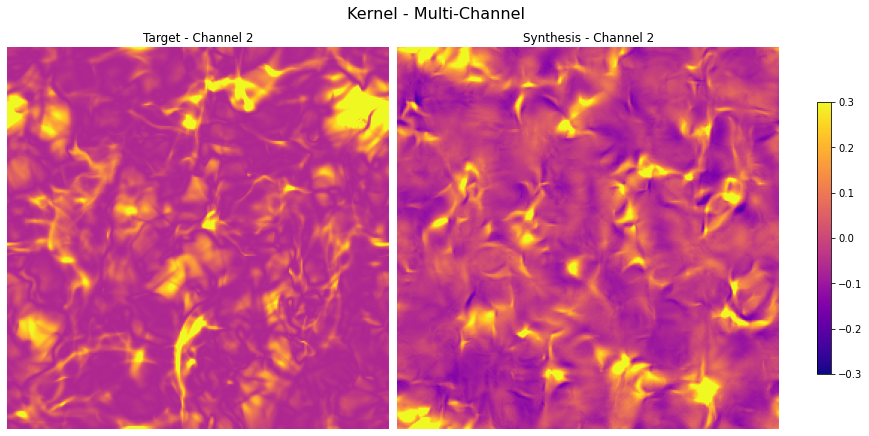

In [16]:
# Plot target vs synthesis for each channel
plot_target_vs_synthesis(data_target_kernel_multi_channel.array[0], u_kernel_multi_channel[0], suptitle = "Kernel - Mult-Channel", titles=["Target - Channel 1", "Synthesis - Channel 1"])
plot_target_vs_synthesis(data_target_kernel_multi_channel.array[1], u_kernel_multi_channel[1], suptitle = "Kernel - Multi-Channel", titles=["Target - Channel 2", "Synthesis - Channel 2"])

#### Many -> Many

In [17]:
im_target = im[:4, 0:1, :, :] # Target image with many maps

# Instantiate kernel data class and related ST operator
data_target_kernel_many_maps = STL_2D_Kernel_Torch(im_target, pbc=True)
st_op_target = data_target_kernel_many_maps.get_ST_op()

# Standardize target data
data_target_kernel_many_maps_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_many_maps, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_many_maps_std)

# Call user-level synthesis-from-statistics wrapper
u_kernel_many_maps = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (4, 1, 256, 256)
[LBFGS] iter 10, loss = 1.066841e+04
[LBFGS] iter 20, loss = 3.346239e+01
[LBFGS] iter 30, loss = 1.779637e+01
[LBFGS] iter 40, loss = 7.537013e+00
[LBFGS] iter 50, loss = 3.268623e+00
[LBFGS] iter 60, loss = 1.564424e+00
[LBFGS] iter 70, loss = 1.000988e+00
[LBFGS] iter 80, loss = 6.969914e-01
[LBFGS] iter 90, loss = 5.296062e-01
[LBFGS] iter 100, loss = 4.302555e-01
[LBFGS] iter 110, loss = 3.640923e-01
110 iterations of synthesis.
Execution time: 20.525 s


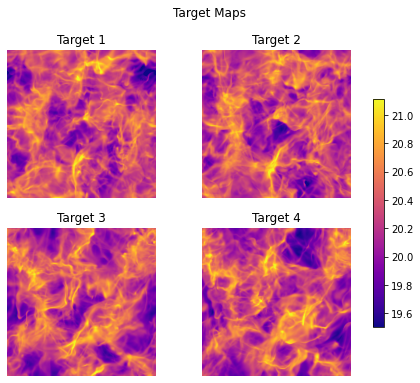

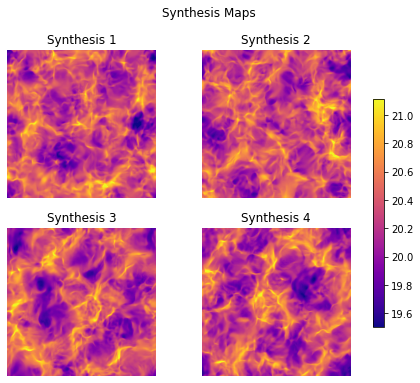

In [19]:
to_numpy = lambda x: x.detach().cpu().numpy()

t_list = [to_numpy(t) for t in data_target_kernel_many_maps.array[:4, 0]]  # 4 maps  
u_list = [to_numpy(u) for u in u_kernel_many_maps[:4]]  # 4 maps

# Flatten target arrays to compute global vmin/vmax
mean_t = np.nanmean(t_list)
std_t = np.nanstd(t_list)

vmin = mean_t - 3 * std_t
vmax = mean_t + 3 * std_t

# --- Plot Target Maps ---
fig_target, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_target.suptitle("Target Maps")

for ax, t, i in zip(axes.flatten(), t_list, range(4)):
    im0 = ax.imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Target {i+1}")

fig_target.colorbar(im0, ax=axes, shrink=0.7)

# --- Plot Synthesis Maps ---
fig_synth, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_synth.suptitle("Synthesis Maps")

for ax, u, i in zip(axes.flatten(), u_list, range(4)):
    im0 = ax.imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Synthesis {i+1}")

fig_synth.colorbar(im0, ax=axes, shrink=0.7)

plt.show()

#### PBC → Non PBC

We observed that for non-periodic images, it is preferable to remove one dyadic scale in scattering statistics estimation compared to the case where the image is periodic. Since the maximum scale of the statistics of periodic target map has already been computed here, we will not apply (at the moment) this max scale adjustment if the image to be synthesized is non periodic.

In [20]:
im_target = im[0, 0, :, :] # Target image (PBC)

# Instantiate kernel data class and related ST operator
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)
st_op_target = data_target_kernel.get_ST_op()

# Standardize target data
data_target_kernel_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel, mean_field=False, inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_std)

# Call user-level synthesis-from-statistics wrapper
u_kernel_no_pbc = synthesize_from_stats(
    target_stats,
    pbc_running=False,
    mean_target=mean_target,
    std_target=std_target
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
[LBFGS] iter 10, loss = 4.305455e+03
[LBFGS] iter 20, loss = 3.196847e+01
[LBFGS] iter 30, loss = 1.073200e+01
[LBFGS] iter 40, loss = 3.514599e+00
[LBFGS] iter 50, loss = 2.163168e+00
[LBFGS] iter 60, loss = 1.448999e+00
[LBFGS] iter 70, loss = 1.047340e+00
[LBFGS] iter 80, loss = 8.682988e-01
[LBFGS] iter 90, loss = 7.577695e-01
[LBFGS] iter 100, loss = 6.921975e-01
[LBFGS] iter 110, loss = 6.331196e-01
110 iterations of synthesis.
Execution time: 15.463 s


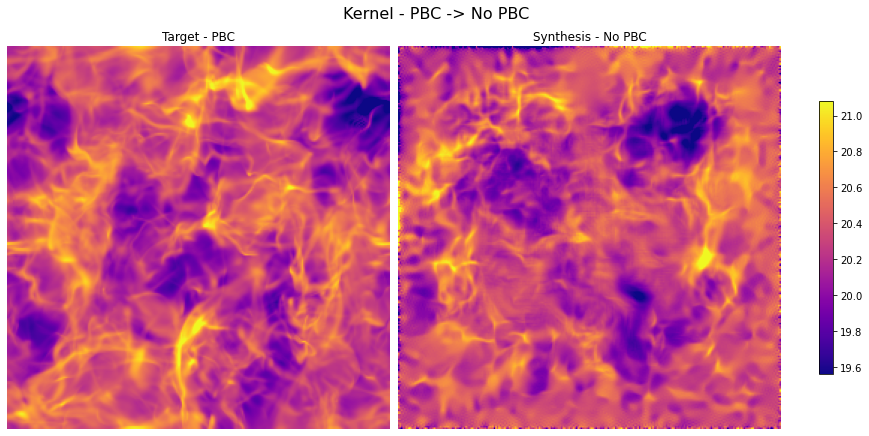

In [21]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_no_pbc, suptitle = "Kernel - PBC -> No PBC", titles=["Target - PBC", "Synthesis - No PBC"])

#### Non PBC → PBC

In [22]:
im_target = im[0, 0, :128, :128] # Target image (no PBC)

# Instantiate kernel data class and related ST operator
data_target_kernel_no_pbc = STL_2D_Kernel_Torch(im_target, pbc=False)
st_op_target = data_target_kernel_no_pbc.get_ST_op()

# Standardize target data (should be performed outside the user-level synthesis-from-statistics wrapper)
data_target_kernel_no_pbc_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_no_pbc, mean_field=False, inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_no_pbc_std)

# Call user-level synthesis-from-statistics wrapper
u_kernel_pbc = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 128, 128)
[LBFGS] iter 10, loss = 2.230662e+03
[LBFGS] iter 20, loss = 7.390601e+01
[LBFGS] iter 30, loss = 1.000691e+01
[LBFGS] iter 40, loss = 5.378363e+00
[LBFGS] iter 50, loss = 3.286954e+00
[LBFGS] iter 60, loss = 2.343511e+00
[LBFGS] iter 70, loss = 1.802222e+00
[LBFGS] iter 80, loss = 1.480325e+00
[LBFGS] iter 90, loss = 1.299258e+00
[LBFGS] iter 100, loss = 1.225801e+00
109 iterations of synthesis.
Execution time: 13.146 s


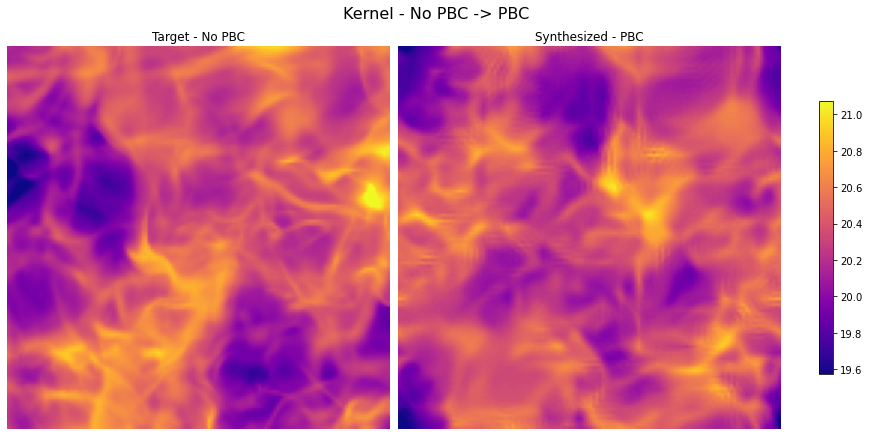

In [23]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_kernel_no_pbc.array, u_kernel_pbc, suptitle = "Kernel - No PBC -> PBC", titles=["Target - No PBC", "Synthesized - PBC"]) 

#### Non PBC → Non PBC

In [24]:
im_target = im[0, 0, :128, :128] # Target image (no PBC)

# Instantiate kernel data class and related ST operator
data_target_kernel_no_pbc = STL_2D_Kernel_Torch(im_target, pbc=False)
st_op_target = data_target_kernel_no_pbc.get_ST_op()

# Standardize target data (should be performed outside the user-level synthesis-from-statistics wrapper)
data_target_kernel_no_pbc_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_no_pbc, mean_field=False, inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_no_pbc_std)

# Call user-level synthesis-from-statistics wrapper
u_kernel_no_pbc = synthesize_from_stats(
    target_stats,
    pbc_running=False,
    mean_target=mean_target,
    std_target=std_target
)

Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 128, 128)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
[LBFGS] iter 10, loss = 3.733287e+03
[LBFGS] iter 20, loss = 2.030636e+01
[LBFGS] iter 30, loss = 1.113795e+01
[LBFGS] iter 40, loss = 6.879952e+00
[LBFGS] iter 50, loss = 4.714982e+00
[LBFGS] iter 60, loss = 3.467612e+00
[LBFGS] iter 70, loss = 2.467104e+00
[LBFGS] iter 80, loss = 2.048298e+00
[LBFGS] iter 90, loss = 1.762628e+00
[LBFGS] iter 100, loss = 1.590339e+00
[LBFGS] iter 110, loss = 1.457399e+00
116 iterations of synthesis.
Execution time: 11.362 s


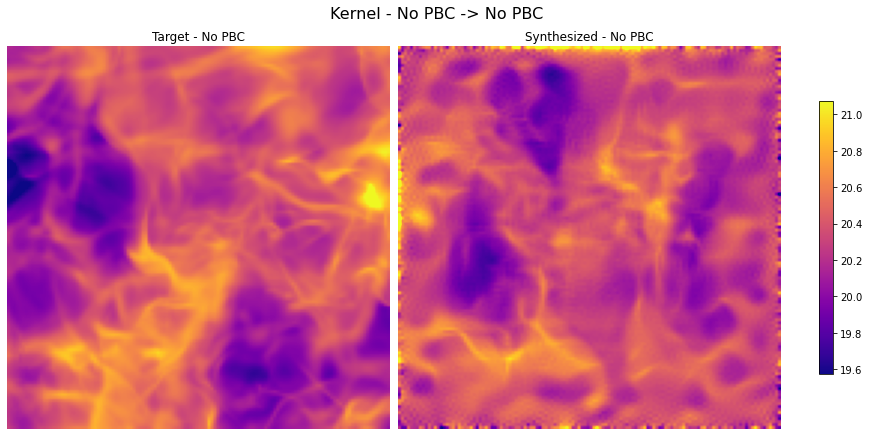

In [25]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_kernel_no_pbc.array, u_kernel_no_pbc, suptitle = "Kernel - No PBC -> No PBC", titles=["Target - No PBC", "Synthesized - No PBC"]) 

#### NaNs → NaNs

For syntheses whose running maps include a mask, it is preferable to increase the number of optimization iterations, as pixels near NaNs generally take longer to converge.

**Notes:** Optimization parameters can be overridden by the user in the `synthesize_from_stats` wrapper, for example the `max_iter` parameter for syntheses whose running maps include a mask.

In [26]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Instantiate kernel data class on NaN target image
data_target_kernel_nan = STL_2D_Kernel_Torch(im_target_nan, pbc=True)
st_op_target = data_target_kernel_nan.get_ST_op()

# Standardize target data
data_target_kernel_nan_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_nan, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_nan_std, compute_PS=False)

# Call user-friendly synthesis wrapper
u_kernel_nan = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    mean_target=mean_target,
    std_target=std_target
)

⚠️ Warning: Power spectrum optimization is disabled because it is not implemented for NaN values in any dataclass and/or because Power spectrum computation has not been included in target_stats.

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.961306e+02
[LBFGS] iter 20, loss = 1.133763e+01
[LBFGS] iter 30, loss = 1.349475e+00
[LBFGS] iter 40, loss = 6.380525e-01
[LBFGS] iter 50, loss = 3.957320e-01
[LBFGS] iter 60, loss = 2.991878e-01
[LBFGS] iter 70, loss = 2.566814e-01
[LBFGS] iter 80, loss = 2.310972e-01
[LBFGS] iter 90, loss = 2.094925e-01
[LBFGS] iter 100, loss = 1.962132e-01
[LBFGS] iter 110, loss = 1.876879e-01
110 iterations of synthesis.
Execution time: 20.189 s
NaN detected in the optimized field, cannot apply Nyquist filter


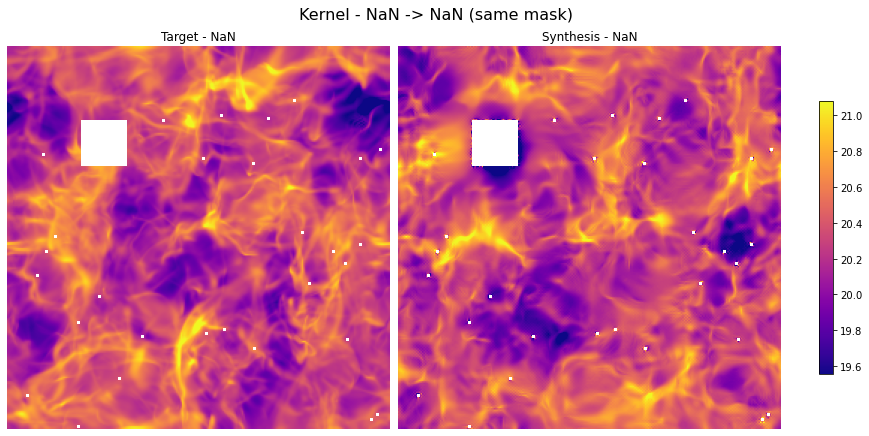

In [28]:
# Plot target vs synthesis for NaN target and NaN synthesis (same mask)
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel_nan, suptitle = "Kernel - NaN -> NaN (same mask)", titles=["Target - NaN", "Synthesis - NaN"])

#### NaNs → NaNs (≠ Mask)

In [29]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Specifiy an array running mask different from the NaN mask of the target image
running_mask = np.zeros_like(im[0, 0, :, :])
running_mask[(np.random.rand(30)*running_mask.shape[0]).astype('int'),
    (np.random.rand(30)*running_mask.shape[0]).astype('int')] = np.nan
running_mask[150:175,150:175] = np.nan

# Instantiate kernel data class and related ST operator
data_target_kernel_nan = STL_2D_Kernel_Torch(im_target_nan, pbc=True)
st_op_target = data_target_kernel_nan.get_ST_op()

# Standardize target data
data_target_kernel_nan_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_nan, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_nan_std, compute_PS=False)

# Call user-friendly synthesis wrapper
u_kernel_nan_new_mask = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    running_mask=running_mask,
    mean_target=mean_target,
    std_target=std_target
)

⚠️ Warning: Power spectrum optimization is disabled because it is not implemented for NaN values in any dataclass and/or because Power spectrum computation has not been included in target_stats.

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.964474e+02
[LBFGS] iter 20, loss = 1.114400e+01
[LBFGS] iter 30, loss = 1.284936e+00
[LBFGS] iter 40, loss = 5.308868e-01
[LBFGS] iter 50, loss = 3.506485e-01
[LBFGS] iter 60, loss = 2.788541e-01
[LBFGS] iter 70, loss = 2.389061e-01
[LBFGS] iter 80, loss = 2.174376e-01
[LBFGS] iter 90, loss = 2.000921e-01
[LBFGS] iter 100, loss = 1.857865e-01
109 iterations of synthesis.
Execution time: 17.614 s
NaN detected in the optimized field, cannot apply Nyquist filter


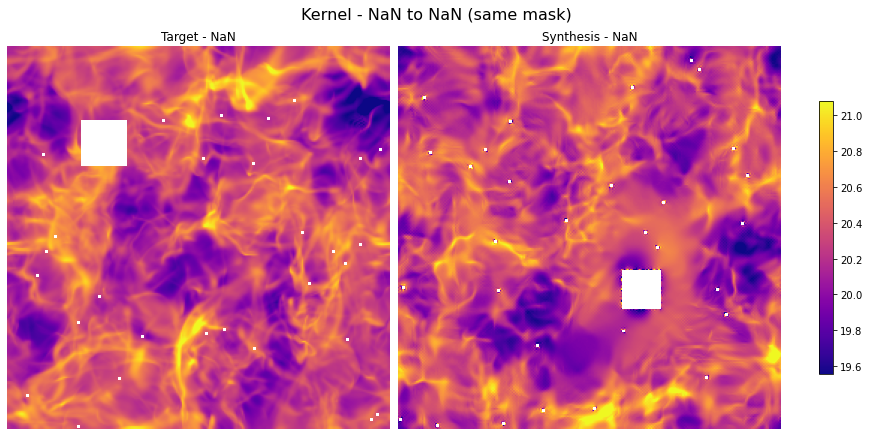

In [30]:
# Plot target vs synthesis for NaN target and NaN synthesis (same mask)
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel_nan_new_mask, suptitle = "Kernel - NaN to NaN (same mask)", titles=["Target - NaN", "Synthesis - NaN"])

#### Non NaNs → NaNs

In [31]:
im_target = im[0, 0, :, :]

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block to a NaN mask 
seed = 26
np.random.seed(seed)

# Instantiate kernel data class and related ST operator
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)
st_op_kernel = data_target_kernel.get_ST_op()

# Standardize target data
data_target_kernel_std, mean_target, std_target = st_op_kernel.wavelet_op.standardize(
    data_target_kernel, 
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_kernel.apply(data_target_kernel_std, compute_PS=False)

# Specifiy an array running mask
running_mask = np.zeros_like(im[0, 0, :, :])
running_mask[(np.random.rand(30)*running_mask.shape[0]).astype('int'),
    (np.random.rand(30)*running_mask.shape[0]).astype('int')] = np.nan
running_mask[50:80,50:80] = np.nan

# Call user-friendly synthesis wrapper
u_kernel_nan = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    running_mask=running_mask,
    mean_target=mean_target,
    std_target=std_target
)

⚠️ Warning: Power spectrum optimization is disabled because it is not implemented for NaN values in any dataclass and/or because Power spectrum computation has not been included in target_stats.

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.972518e+02
[LBFGS] iter 20, loss = 1.122352e+01
[LBFGS] iter 30, loss = 1.347833e+00
[LBFGS] iter 40, loss = 5.690782e-01
[LBFGS] iter 50, loss = 3.782798e-01
[LBFGS] iter 60, loss = 2.843462e-01
[LBFGS] iter 70, loss = 2.362913e-01
[LBFGS] iter 80, loss = 2.070480e-01
[LBFGS] iter 90, loss = 1.880588e-01
[LBFGS] iter 100, loss = 1.753809e-01
109 iterations of synthesis.
Execution time: 18.385 s
NaN detected in the optimized field, cannot apply Nyquist filter


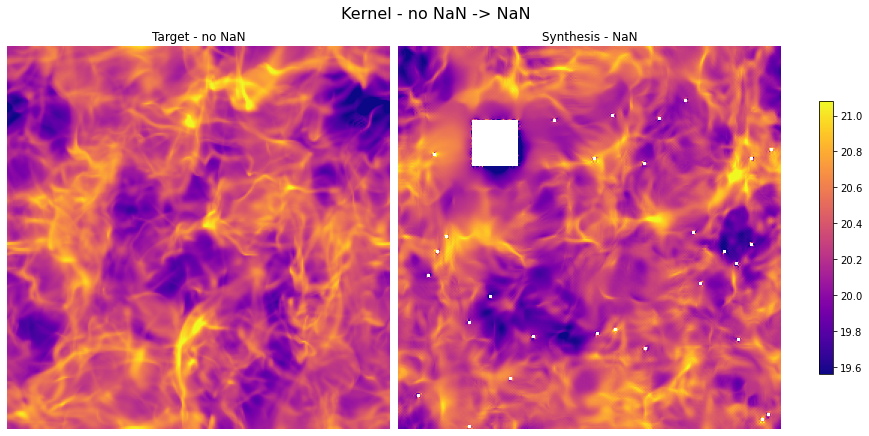

In [33]:
# Plot target vs synthesis for NaN target and NaN synthesis (same mask)
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_nan, suptitle = "Kernel - no NaN -> NaN", titles=["Target - no NaN", "Synthesis - NaN"])

#### NaNs → Non NaNs

In [34]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Instantiate kernel data class and related ST operator
data_target_kernel_nan = STL_2D_Kernel_Torch(im_target_nan, pbc=True)
st_op_target = data_target_kernel_nan.get_ST_op()

# Standardize target data
data_target_kernel_nan_std, mean_target, std_target = st_op_target.wavelet_op.standardize(
    data_target_kernel_nan,
    mean_field=False, 
    inplace=False
)

# Compute target statistics
target_stats = st_op_target.apply(data_target_kernel_nan_std, compute_PS=False)

# Call user-friendly synthesis wrapper
u_kernel = synthesize_from_stats(
    target_stats,
    pbc_running=True,
    running_mask=np.zeros_like(im[0, 0, :, :]),
    mean_target=mean_target,
    std_target=std_target
)

⚠️ Warning: Power spectrum optimization is disabled because it is not implemented for NaN values in any dataclass and/or because Power spectrum computation has not been included in target_stats.

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
[LBFGS] iter 10, loss = 1.969849e+02
[LBFGS] iter 20, loss = 1.190005e+01
[LBFGS] iter 30, loss = 1.322651e+00
[LBFGS] iter 40, loss = 5.555318e-01
[LBFGS] iter 50, loss = 3.411455e-01
[LBFGS] iter 60, loss = 2.666459e-01
[LBFGS] iter 70, loss = 2.241529e-01
[LBFGS] iter 80, loss = 1.937611e-01
[LBFGS] iter 90, loss = 1.764513e-01
[LBFGS] iter 100, loss = 1.592381e-01
[LBFGS] iter 110, loss = 1.455836e-01
113 iterations of synthesis.
Execution time: 18.886 s


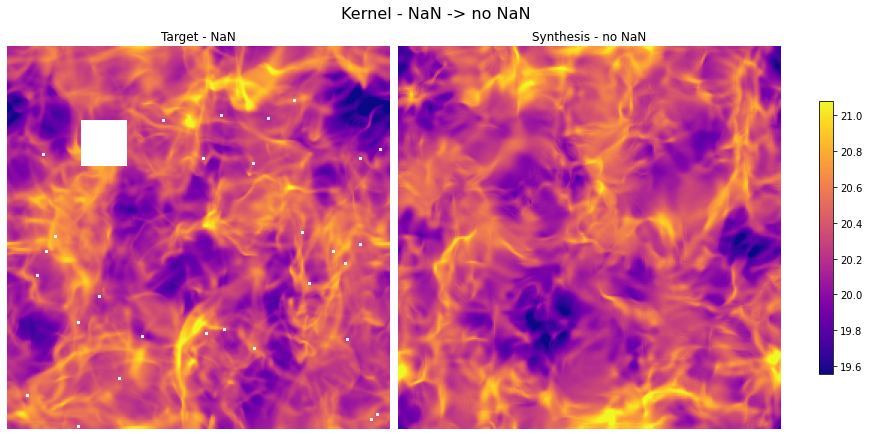

In [36]:
# Plot target vs synthesis for NaN target and NaN synthesis (same mask)
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel, suptitle = "Kernel - NaN -> no NaN", titles=["Target - NaN", "Synthesis - no NaN"])